# Sample-based Krylov Quantum Diagonalization (SKQD) with multiple reference systems

In [1]:
import warnings
import matplotlib.pyplot as plt
import numpy as np

from qiskit import generate_preset_pass_manager
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import SamplerV2 as Sampler

from common.hamiltonians import build_LiH_hamiltonian, build_N2_strongly_correlated_hamiltonian
from common.states import neel_state
from common.time_evolution_circuit import initial_circuit, build_krylov_measurement_circuits
from common.measurement_processing import extract_counts_sim, cumulative_counts, cumulative_counts_multiple_references
from common.sqd_energies import sqd_energies_from_cumulative

warnings.filterwarnings("ignore")

### 1. Map problem to quantum circuits and operators

In [6]:
# Define Hamiltonian

# LiH
# H_op = build_LiH_hamiltonian()
# num_qubits = 10

# N2
H_op = build_N2_strongly_correlated_hamiltonian()
num_qubits = 12

# Set parameters for quantum Krylov algorithm
krylov_dim = 10
dt = 0.15
num_trotter_steps = 6

accuracy of Cholesky decomposition  1.1102230246253459e-16


In [18]:
# Prep `Neel` state as the reference state for evolution

# qc_ref0 = neel_state(num_qubits, shift=0)  # IBM baseline reference (Φ0)
# qc_ref1 = neel_state(num_qubits, shift=1)  # second reference (Φ1)


from qiskit import QuantumCircuit

def slater_det_ref(ncas, occ_alpha, occ_beta):
    n = 2 * ncas
    qc = QuantumCircuit(n)
    for p in occ_alpha:
        qc.x(p)          # alpha qubits: 0..ncas-1
    for p in occ_beta:
        qc.x(ncas + p)   # beta qubits: ncas..2*ncas-1
    return qc

#LiH
# qc_ref0 = slater_det_ref(ncas=int(num_qubits/2), occ_alpha=[0], occ_beta=[0]) # (α0,β0)
# qc_ref1 = slater_det_ref(ncas=int(num_qubits/2), occ_alpha=[1], occ_beta=[1]) # (α1,β1)

#N2
qc_ref0 = slater_det_ref(ncas=int(num_qubits/2), occ_alpha=[0,1,2], occ_beta=[0,1,2])  # (α0,β0)
qc_ref1 = slater_det_ref(ncas=int(num_qubits/2), occ_alpha=[0,1,3], occ_beta=[0,1,3])  # (α1,β1)

ref_preps_single = [qc_ref0]             # d=1 (IBM baseline)
ref_preps_multi  = [qc_ref0, qc_ref1]    # d=2 (multireference)


In [19]:
# Initialize time evolution circuits
qc_evol = initial_circuit(H_op, dt, num_trotter_steps, num_qubits)

circuits_single, labels_single = build_krylov_measurement_circuits(
    ref_preps_single, krylov_dim, qc_evol
)
circuits_multi, labels_multi = build_krylov_measurement_circuits(
    ref_preps_multi, krylov_dim, qc_evol
)

print("single circuits:", len(circuits_single), "labels example:", labels_single[:3])
print("multi  circuits:", len(circuits_multi),  "labels example:", labels_multi[:3])

single circuits: 10 labels example: [(0, 0), (0, 1), (0, 2)]
multi  circuits: 20 labels example: [(0, 0), (0, 1), (0, 2)]


### 2. Optimize for target hardware

In [20]:
backend = AerSimulator(seed_simulator=12345)

pm = generate_preset_pass_manager(backend=backend, optimization_level=3)

isa_single = pm.run(circuits=circuits_single)
isa_multi  = pm.run(circuits=circuits_multi)

### 3. Execute on target hardware

In [21]:
shots = 5_000
sampler = Sampler()

job_single = sampler.run(isa_single, shots=shots)
job_multi  = sampler.run(isa_multi,  shots=shots)

res_single = job_single.result()
res_multi  = job_multi.result()

In [22]:
counts_single_all = [extract_counts_sim(res_single, k) for k in range(krylov_dim)]
counts_multi_all  = [extract_counts_sim(res_multi,  k) for k in range(len(isa_multi))]

print("Example single counts keys:", list(counts_single_all[0].keys())[:3])
print("Example multi counts keys :", list(counts_multi_all[0].keys())[:3])

Example single counts keys: ['000111000111']
Example multi counts keys : ['000111000111']


### 4. Post-process results

In [23]:
# Get cumulative counts from the measurements

# IBM baseline cumulative (Φ0 only)
counts_single_cum = cumulative_counts(counts_single_all)

# multiple references
counts_multi_cum = cumulative_counts_multiple_references(labels_multi, counts_multi_all, krylov_dim, ref_preps_multi)
print("Built pooled multiref cumulative list length:", len(counts_multi_cum))

Built pooled multiref cumulative list length: 10


In [25]:
# num_ones = num_qubits // 2
# scipy_kwargs = {"k": 2, "which": "SA"}
# Lih
# print("Single reference:")
# ener_single = sqd_energies_from_cumulative(counts_single_cum, H_op, num_qubits, num_ones=2)
#
# print("Multiple references:")
# ener_multi  = sqd_energies_from_cumulative(counts_multi_cum,  H_op, num_qubits, num_ones=2)

# N2
print("Single reference:")
ener_single = sqd_energies_from_cumulative(counts_single_cum, H_op, num_qubits, num_ones=6)

print("Multiple references:")
ener_multi  = sqd_energies_from_cumulative(counts_multi_cum,  H_op, num_qubits, num_ones=6)

Single reference:
[step 1] subspace N=1 -> E0=-106.871504
[step 2] subspace N=1 -> E0=-106.871504
[step 3] subspace N=7 -> E0=-107.172176
[step 4] subspace N=14 -> E0=-107.283629
[step 5] subspace N=17 -> E0=-107.287026
[step 6] subspace N=17 -> E0=-107.287026
[step 7] subspace N=18 -> E0=-107.287118
[step 8] subspace N=19 -> E0=-107.303235
[step 9] subspace N=20 -> E0=-107.303239
[step 10] subspace N=21 -> E0=-107.303248
Multiple references:
[step 1] subspace N=2 -> E0=-107.072067
[step 2] subspace N=5 -> E0=-107.144484
[step 3] subspace N=12 -> E0=-107.290101
[step 4] subspace N=21 -> E0=-107.349327
[step 5] subspace N=22 -> E0=-107.357746
[step 6] subspace N=25 -> E0=-107.359285
[step 7] subspace N=29 -> E0=-107.376568
[step 8] subspace N=30 -> E0=-107.379000
[step 9] subspace N=33 -> E0=-107.404492
[step 10] subspace N=34 -> E0=-107.406809


In [26]:
import numpy as np

def ground_energy_dense(H):
    # H: qiskit.quantum_info.SparsePauliOp
    Hmat = H.to_matrix()                 # dense (2^n x 2^n)
    evals = np.linalg.eigvalsh(Hmat)     # Hermitian eigs
    return float(evals[0].real)

E0 = ground_energy_dense(H_op)
print("Ground energy:", E0)

Ground energy: -107.43702368448315


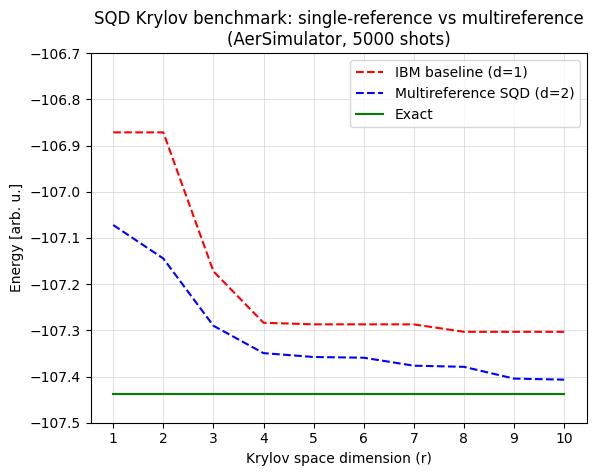

In [28]:
exact_gs_en = E0
xs = np.arange(1, krylov_dim + 1)
plt.grid(True, which='both', color='lightgray', linestyle='-', linewidth=0.5, alpha=1)
plt.plot(
    xs,
    ener_single,
    color="red",
    linestyle="--",
    label="IBM baseline (d=1)"
)
plt.plot(
    xs,
    ener_multi,
    color="blue",
    linestyle="--",
    label="Multireference SQD (d=2)"
)
plt.plot(
    xs,
    [exact_gs_en]*krylov_dim,
    color="green",
    linestyle="-",
    label="Exact"
)

plt.xticks(xs, xs)
plt.xlabel("Krylov space dimension (r)")
plt.ylabel("Energy [arb. u.]")
plt.title(f"SQD Krylov benchmark: single-reference vs multireference\n(AerSimulator, {shots} shots)")
plt.ylim([-107.5, -106.7])
plt.legend()
plt.show()